# **Investigación Operativa Superior -  Forecasting + Gestión de Stocks**


#### **¿Por qué importa el forecasting de demanda?**

En gestión industrial, casi toda decisión de planificación depende de una pregunta central:
**¿cuánto vamos a necesitar, y cuándo?**

Sin una estimación de demanda, los modelos de IO operan en el vacío:

- El **EOQ** y los modelos de inventario asumen una demanda conocida — si esa demanda es incorrecta, el "óptimo" es una ilusión
- El **MRP** explota requerimientos a partir de un plan maestro que necesita forecast como input
- La **programación de la producción** (job shop, flow shop) no puede minimizar makespan ni tardanza sin saber qué órdenes van a entrar
- El **dimensionamiento de recursos** (workforce planning, capacidad) requiere anticipar carga futura

En la práctica, la demanda nunca es determinística. Tiene estacionalidad, tendencia, ruido, y a veces shocks externos. El forecasting no busca predecir el futuro con certeza — busca **reducir la incertidumbre lo suficiente** como para que las decisiones de planificación sean robustas.

Un buen forecast no reemplaza al modelo de optimización: lo *alimenta*.
La cadena es siempre: **forecast → política de inventario → plan de producción → scheduling**.
Cada eslabón amplifica o amortigua el error del anterior — lo que se conoce como el **efecto látigo** (*bullwhip effect*).

Por eso el forecasting no es un problema estadístico aislado: es el primer paso de toda la cadena de planificación operativa.

#### **Objetivos de la clase:**
1. Repasar conceptos fundamentales de Machine Learning
2. Entender las particularidades de series de tiempo y como aplicar algoritmos de ML para este problema
3. Aplicar modelos de forecasting con Nixtla (MLForecast)
4. Conectar pronósticos con modelos de gestión de inventarios clasicos y basados en simulación de MonteCarlo

**Stack:** Python, pandas, Nixtla MLForecast, statsforecast, LightGBM


## **1) Conceptos Fundamentales de Machine Learning**


### 1.1 ¿Qué es el Machine Learning?

Machine Learning es un enfoque donde **los modelos aprenden patrones a partir de datos**, en lugar de ser programados con reglas explícitas.

### Tipos principales:

| Tipo | Descripción | Ejemplo en IO |
|------|------------|---------------|
| **Supervisado** | Aprende de pares (X, y) | Predecir demanda futura |
| **No supervisado** | Encuentra estructura sin etiquetas | Segmentar productos por patrón de venta |
| **Reinforcement** | Aprende por prueba/error | Políticas dinámicas de reposición |

En esta práctica nos enfocamos en **aprendizaje supervisado** aplicado a **series de tiempo**.

<img src="data/ml_vs_program.png" alt="Machine Learning vs Programación Tradicional" width="500"/>

### 1.2 El pipeline clásico de ML supervisado

```
Datos crudos → Feature Engineering → Train/Test Split → Entrenamiento → Evaluación → Predicción
```

### Conceptos clave:

- **Features (X):** Variables que el modelo usa para predecir. Ej: día de la semana, mes, lag de ventas.
- **Target (y):** Lo que queremos predecir. Ej: ventas de la próxima semana.
- **Train/Test Split:** Separar datos para entrenar y para evaluar. **En series de tiempo, siempre es temporal** (no aleatorio).
- **Overfitting:** El modelo memoriza el train pero no generaliza. Es el enemigo #1.
- **Underfitting:** El modelo es demasiado simple para capturar los patrones.

### 1.3 Métricas de evaluación

Para forecasting usamos métricas que miden qué tan lejos está nuestra predicción de la realidad:

| Métrica | Fórmula | Interpretación |
|---------|---------|----------------|
| **MAE** | $\frac{1}{n}\sum|y_i - \hat{y}_i|$ | Error absoluto promedio (mismas unidades que y) |
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Penaliza más los errores grandes |
| **MAPE** | $\frac{1}{n}\sum\frac{|y_i - \hat{y}_i|}{|y_i|}$ | Error porcentual (problemas con valores cercanos a 0) |
| **SMAPE** | $\frac{1}{n}\sum\frac{2|y_i - \hat{y}_i|}{|y_i|+|\hat{y}_i|}$ | Versión simétrica del MAPE |

**¿Cuál usar?** Depende del contexto de negocio:

### 1.4 Visualización: Overfitting vs Underfitting

/var/folders/36/xhls1xbs1676nkndj0s_rtnr0000gn/T/ipykernel_94314/1264949969.py:28: RankWarning: Polyfit may be poorly conditioned
  z3 = np.polyfit(x, y, 20)


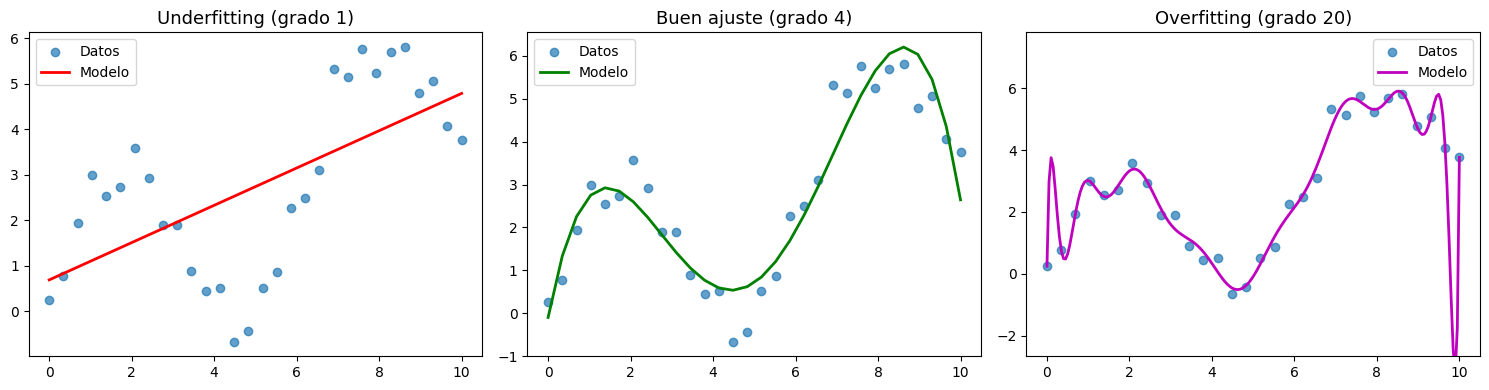

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generamos datos sintéticos con tendencia + ruido
np.random.seed(42)
x = np.linspace(0, 10, 30)
y = 2 * np.sin(x) + 0.5 * x + np.random.normal(0, 0.5, len(x))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Underfitting: modelo lineal
z1 = np.polyfit(x, y, 1)
p1 = np.poly1d(z1)
axes[0].scatter(x, y, alpha=0.7, label='Datos')
axes[0].plot(x, p1(x), 'r-', linewidth=2, label='Modelo')
axes[0].set_title('Underfitting (grado 1)', fontsize=13)
axes[0].legend()

# Buen ajuste
z2 = np.polyfit(x, y, 4)
p2 = np.poly1d(z2)
axes[1].scatter(x, y, alpha=0.7, label='Datos')
axes[1].plot(x, p2(x), 'g-', linewidth=2, label='Modelo')
axes[1].set_title('Buen ajuste (grado 4)', fontsize=13)
axes[1].legend()

# Overfitting
z3 = np.polyfit(x, y, 20)
p3 = np.poly1d(z3)
x_fine = np.linspace(0, 10, 200)
axes[2].scatter(x, y, alpha=0.7, label='Datos')
axes[2].plot(x_fine, p3(x_fine), 'm-', linewidth=2, label='Modelo')
axes[2].set_ylim(y.min()-2, y.max()+2)
axes[2].set_title('Overfitting (grado 20)', fontsize=13)
axes[2].legend()

plt.tight_layout()
plt.show()

#### **Cómo aprende un modelo?**

Los modelos _ajustan sus parametros_ minimizando una funcion de error entre lo que produce el modelo y lo que _deberia producir_. En ingles y en el mundo ML conocemos a este valor de "Y verdadero" como "Ground Truth". Si bien existen variantes, la mayoria de modelos de Ml aprenden a minimizar dicha funcion de error (o "funcion de perdida") usando el algoritmo del Descenso del Gradiente

<img src="data/gd_plot.png" alt="Gradient Descent Illustration" width="500"/>

A grandes rasgos, el algoritmo consiste en calcular las derivadas parciales de la funcion de perdida con respecto a los parametros del modelo, conformando el gradiente de la funcion en cada punto del espacio, y luego en "moverse" en la direccion opuesta al gradiente, hasta converger a un minimo de la funcion de perdida. 

#### **Ejemplo clasico de regresión supervisada:**

- Predecir el precio de una casa con respecto a sus caracteristicas
- Problemas tipicos de Estadistica Aplicada II / Estadistica aplicada



## **2) Series de Tiempo - Lo que cambia respecto a ML tabular**

<img src="data/ts_plot.png" alt="Serie de Tiempo Ejemplo" width="600"/>

### 2.1 ¿Qué es una serie de tiempo?

Una secuencia de observaciones **indexadas en el tiempo**. A diferencia de datos tabulares:

| ML Tabular | Series de Tiempo |
|-----------|------------------|
| Observaciones i.i.d. | Observaciones correlacionadas temporalmente |
| Train/test aleatorio | Train/test **temporal** (el futuro no puede entrenar al pasado) |
| Features explícitos | Features derivados del tiempo: lags, rolling stats, estacionalidad |
| Una predicción | Horizonte de predicción (h pasos adelante) |

#### Algunos componentes de una serie:
- **Tendencia:** Dirección a largo plazo (creciente, decreciente, plana)
- **Estacionalidad:** Patrones repetitivos (semanal, mensual, anual)
- **Ruido:** Variación aleatoria
- **Ciclo:** Fluctuaciones de largo plazo no periódicas

#### Si recordamos de nuestras clases de estadistica, los supuestos formales de la regresión lineal decian que:

1. **Linealidad** — la relación entre X e Y es lineal en los parámetros
2. **Exogeneidad** — $E[\varepsilon_i | X] = 0$ — los errores no se correlacionan con las X
3. **Homocedasticidad** — $Var(\varepsilon_i | X) = \sigma^2 \ \forall i$ — varianza del error constante
4. **No autocorrelación** — $Cov(\varepsilon_i, \varepsilon_j) = 0 \ \forall i \neq j$ — errores independientes entre sí
5. **No multicolinealidad perfecta** — las X no son combinación lineal exacta entre sí
6. **Normalidad de los errores** — $\varepsilon_i \sim N(0, \sigma^2)$ — necesario para inferencia en muestras chicas

### 2.2 Creemos una serie sintética para entender los componentes

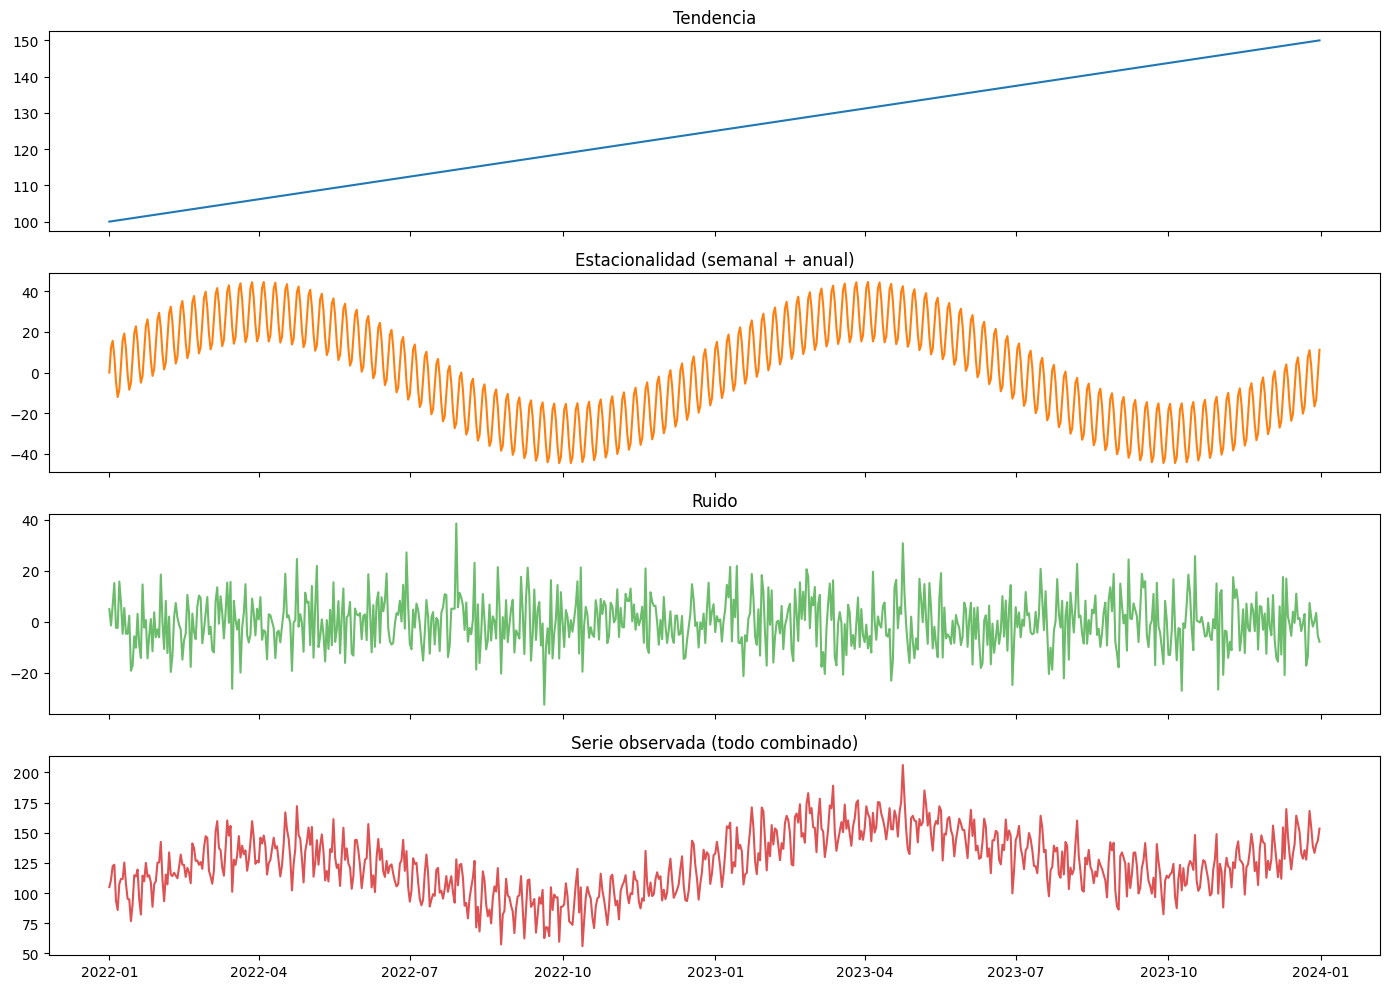

In [2]:
import pandas as pd

# Simulamos 2 años de ventas diarias
np.random.seed(42)
n_days = 730
dates = pd.date_range('2022-01-01', periods=n_days, freq='D')

# Componentes
tendencia = np.linspace(100, 150, n_days)  # crecimiento gradual
estacionalidad_semanal = 15 * np.sin(2 * np.pi * np.arange(n_days) / 7)  # ciclo semanal
estacionalidad_anual = 30 * np.sin(2 * np.pi * np.arange(n_days) / 365)  # ciclo anual
ruido = np.random.normal(0, 10, n_days)

ventas = tendencia + estacionalidad_semanal + estacionalidad_anual + ruido
ventas = np.maximum(ventas, 0)  # ventas no negativas

df_sintetico = pd.DataFrame({'ds': dates, 'y': ventas})

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(dates, tendencia, color='tab:blue')
axes[0].set_title('Tendencia')

axes[1].plot(dates, estacionalidad_semanal + estacionalidad_anual, color='tab:orange')
axes[1].set_title('Estacionalidad (semanal + anual)')

axes[2].plot(dates, ruido, color='tab:green', alpha=0.7)
axes[2].set_title('Ruido')

axes[3].plot(dates, ventas, color='tab:red', alpha=0.8)
axes[3].set_title('Serie observada (todo combinado)')

plt.tight_layout()
plt.show()

### 2.3 Train/Test Split temporal

**Regla de oro:** Nunca usar datos del futuro para entrenar.

```
                    cutoff
  ├──── TRAIN ────────┤──── TEST ────┤
  t=0                 t=T-h          t=T
```

Para evaluación robusta se usa **backtesting** (ventana deslizante).

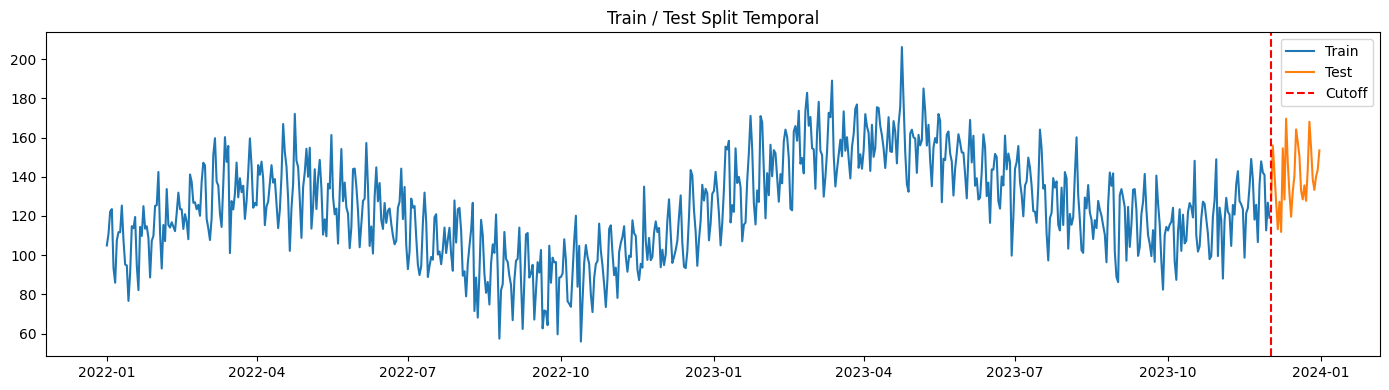

Train: 700 días (2022-01-01 a 2023-12-01)
Test:  30 días (2023-12-02 a 2023-12-31)


In [3]:
# Split temporal: últimos 30 días como test
horizon = 30
df_train = df_sintetico.iloc[:-horizon]
df_test = df_sintetico.iloc[-horizon:]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_train['ds'], df_train['y'], label='Train', color='tab:blue')
ax.plot(df_test['ds'], df_test['y'], label='Test', color='tab:orange')
ax.axvline(df_test['ds'].iloc[0], color='red', linestyle='--', label='Cutoff')
ax.legend()
ax.set_title('Train / Test Split Temporal')
plt.tight_layout()
plt.show()

print(f"Train: {len(df_train)} días ({df_train['ds'].min().date()} a {df_train['ds'].max().date()})")
print(f"Test:  {len(df_test)} días ({df_test['ds'].min().date()} a {df_test['ds'].max().date()})")

### Backtesting de modelos: Evaluar y medir error en multiples horizontes moviles


![Backtesting sliding window](data/ChainedWindows.gif)

> Medir el error en un horizonte especifico puede ser engañoso. Nada nos asegura que ese horizonte especifico sea representativo de la realidad y que el modelo generalize bien por performar bien ahi. Por eso --> intentamos reducir esta incertidumbre evaluando el modelo en mas de un horizonte con Backtesting. El modelo va viendo "de a poco" la data, moviendose hacia el futuro como si estuviera haciendo predicciones reales. Evaluamos al modelo en cada split y luego agregamos las metricas


## **3) Forecasting con Nixtla (MLForecast)**


### 3.1 ¿Por qué Nixtla?

[Nixtla](https://nixtla.io/) es un ecosistema open-source de forecasting que incluye:

- **StatsForecast:** Modelos estadísticos (ETS, ARIMA, Theta, etc.) - extremadamente rápidos
- **MLForecast:** ML aplicado a series de tiempo (LightGBM, XGBoost, etc.)
- **NeuralForecast:** Deep learning (N-BEATS, TFT, PatchTST, etc.)
- Otras librerias como TimeGPT y usos mas avanzados

### ¿Por qué es útil para problemas de demand forecasting?

- Pensado para escala industrial. Maneja **múltiples series** eficientemente (Miles de SKUs)
- Feature engineering automático (lags, rolling means, etc.) --> Si usaramos pandas + sklearn tendriamos que construir cada uno.
- Mucho mas rapido que modelos de series temporales estadisticos clasicos (Flia ARIMA y variantes). Un solo modelo global para todos los productos.
- Evaluación con cross-validation temporal built-in + otros features super utiles.


### 3.2 Setup e instalación

In [ ]:
# Instalar las librerías necesarias (descomentar si es necesario)
!pip install mlforecast statsforecast lightgbm datasetsforecast utilsforecast

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
import lightgbm as lgb
from sklearn.linear_model import LinearRegression

from statsforecast import StatsForecast
from statsforecast.models import AutoETS, SeasonalNaive, Naive

from utilsforecast.losses import mae, rmse, smape
from utilsforecast.evaluation import evaluate

print("✅ Librerías cargadas correctamente")

✅ Librerías cargadas correctamente


### 3.3 Dataset VN2: Ventas reales

Usamos el dataset **VN2** que contiene series de ventas con frecuencia diversa. Es un dataset clásico de benchmarking de forecasting.


In [ ]:
# TODO

In [ ]:
# Visualizar algunas series TODO

### 3.5 Baselines: Modelos ingenuos (¡siempre empezar por acá!)

Independientemente del modelo que usemos, necesitamos **baselines** simples para comparar:

- **Naive:** Repetir el último valor observado
- **SeasonalNaive:** Repetir el patrón del último ciclo estacional
- **AutoETS:** Modelo estadístico que captura tendencia + estacionalidad automáticamente

> 💡 Si tu modelo de ML no supera a SeasonalNaive, probablemente algo anda mal. O bien el modelo esta roto, o la serie no tiene suficiente informacion para poder predecirla!

In [ ]:
# Baselines con StatsForecast
sf = StatsForecast(
    models=[
        Naive(),
        SeasonalNaive(season_length=12),  # estacionalidad mensual = 12
        AutoETS(season_length=12),
    ],
    freq='MS',  # Monthly Start
    n_jobs=-1,
)

# Entrenar y predecir
sf.fit(df_train)
baselines_pred = sf.predict(h=HORIZON)
baselines_pred = baselines_pred.reset_index()

print("Predicciones baseline generadas:")
baselines_pred.head()

### 3.6 MLForecast: Machine Learning para series de tiempo

### ¿Cómo funciona?

MLForecast convierte el problema de series de tiempo en un problema **tabular supervisado** y genera **features temporales** dinamicamente para que los modelos puedan aprender a predecir el futuro:

1. **Lags:** Valores pasados como features → `lag_1`, `lag_2`, ..., `lag_12`
2. **Rolling statistics:** Media/desviación móvil → `rolling_mean_7`, `rolling_std_30`
3. **Features de fecha:** Mes, día de la semana, trimestre, etc.
4. **Target transforms:** Diferenciación para remover tendencia


```
Serie: [100, 105, 103, 110, 108, ...]
                    ↓
| lag_1 | lag_2 | lag_12 | rolling_mean_3 | month | → y |
|-------|-------|--------|----------------|-------|-----|
| 108   | 110   | 100    | 106            | 6     | 112 |
```

In [ ]:
from window_ops.rolling import rolling_mean, rolling_std

# Configuración de MLForecast
mlf = MLForecast(
    models={
        'LightGBM': lgb.LGBMRegressor(
            n_estimators=100,
            learning_rate=0.1,
            num_leaves=31,
            verbosity=-1,
            random_state=42,
        ),
        'LinearRegression': LinearRegression(),
    },
    freq='MS',
    lags=[1, 2, 3, 6, 12],               # Valores pasados como features
    lag_transforms={                       # Estadísticas móviles
        1: [(rolling_mean, 3), (rolling_mean, 6), (rolling_mean, 12)],
        12: [(rolling_mean, 3)],
    },
    date_features=['month', 'quarter'],    # Features del calendario
    target_transforms=[Differences([12])], # Diferenciación estacional
)

# Entrenar
mlf.fit(df_train)
print("✅ MLForecast entrenado")

In [ ]:
# Ver qué features se generaron
print("Features generados automáticamente:")
print(mlf.ts.features_order_)

In [ ]:
# Predecir
ml_pred = mlf.predict(h=HORIZON)
ml_pred = ml_pred.reset_index()

print("Predicciones ML generadas:")
ml_pred.head()

### 3.7 Evaluación comparativa

In [ ]:
# Unir todas las predicciones con los valores reales
all_preds = df_test[['unique_id', 'ds', 'y']].copy()
all_preds = all_preds.merge(baselines_pred, on=['unique_id', 'ds'], how='left')
all_preds = all_preds.merge(ml_pred, on=['unique_id', 'ds'], how='left')

# Calcular métricas por modelo
model_cols = ['Naive', 'SeasonalNaive', 'AutoETS', 'LightGBM', 'LinearRegression']

results = []
for model in model_cols:
    if model in all_preds.columns:
        valid = all_preds.dropna(subset=[model])
        if len(valid) > 0:
            mae_val = np.mean(np.abs(valid['y'] - valid[model]))
            rmse_val = np.sqrt(np.mean((valid['y'] - valid[model])**2))
            # SMAPE
            smape_val = np.mean(2 * np.abs(valid['y'] - valid[model]) / (np.abs(valid['y']) + np.abs(valid[model]) + 1e-8)) * 100
            results.append({'Modelo': model, 'MAE': round(mae_val, 2), 'RMSE': round(rmse_val, 2), 'SMAPE (%)': round(smape_val, 2)})

df_results = pd.DataFrame(results).sort_values('MAE')
print("📊 Comparación de modelos:")
print("="*60)
df_results

In [ ]:
# Visualizar predicciones vs realidad para algunas series
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, sid in zip(axes.flat, sample_ids[:6]):
    # Histórico
    train_s = df_train[df_train['unique_id'] == sid]
    test_s = df_test[df_test['unique_id'] == sid]
    preds_s = all_preds[all_preds['unique_id'] == sid]
    
    # Últimos 36 meses de train + test
    ax.plot(train_s['ds'].tail(36), train_s['y'].tail(36), 
            color='black', label='Histórico', linewidth=1.5)
    ax.plot(test_s['ds'], test_s['y'], 
            color='black', linestyle='--', label='Real', linewidth=1.5)
    
    # Predicciones
    if 'SeasonalNaive' in preds_s.columns:
        ax.plot(preds_s['ds'], preds_s['SeasonalNaive'], 
                label='SeasonalNaive', alpha=0.7)
    if 'LightGBM' in preds_s.columns:
        ax.plot(preds_s['ds'], preds_s['LightGBM'], 
                label='LightGBM', alpha=0.7)
    if 'AutoETS' in preds_s.columns:
        ax.plot(preds_s['ds'], preds_s['AutoETS'], 
                label='AutoETS', alpha=0.7)
    
    ax.set_title(sid, fontsize=11)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Predicciones vs Realidad', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 3.8 Cross-Validation temporal (backtesting)

Una sola ventana de test no es confiable. Usamos **cross-validation temporal**:

```
Ventana 1: [====TRAIN====][TEST]
Ventana 2: [=====TRAIN=====][TEST]
Ventana 3: [======TRAIN======][TEST]
```

Esto nos da una estimación más robusta del error real.

In [ ]:
# Cross-validation con MLForecast
cv_results = mlf.cross_validation(
    df=df,
    h=HORIZON,
    n_windows=3,      # 3 ventanas de evaluación
    step_size=HORIZON, # Mover ventana por HORIZON períodos
)

print(f"Cross-validation completada")
print(f"Ventanas: {cv_results['cutoff'].nunique()}")
print(f"Observaciones totales: {len(cv_results)}")
cv_results.head()

In [ ]:
# Métricas de CV por ventana
cv_metrics = []
for cutoff in cv_results['cutoff'].unique():
    window = cv_results[cv_results['cutoff'] == cutoff]
    for model in ['LightGBM', 'LinearRegression']:
        if model in window.columns:
            mae_val = np.mean(np.abs(window['y'] - window[model]))
            cv_metrics.append({
                'Cutoff': cutoff.strftime('%Y-%m'),
                'Modelo': model,
                'MAE': round(mae_val, 2)
            })

df_cv_metrics = pd.DataFrame(cv_metrics)
print("📊 MAE por ventana de cross-validation:")
df_cv_metrics.pivot(index='Cutoff', columns='Modelo', values='MAE')


## **4) Del forecast de demanda a la decisión de stock**

### 4.1 ¿Por qué importa el pronóstico para inventarios?

El forecast es **input fundamental** de cualquier modelo de inventarios:

```
    Forecast de demanda
           ↓
    ¿Cuánto pedir? → Cantidad de orden (Q)
    ¿Cuándo pedir? → Punto de reorden (ROP)
    ¿Cuánto stock de seguridad? → Safety Stock (SS)
```

#### Modelo básico: Punto de Reorden con Stock de Seguridad

$$ROP = \bar{d} \cdot L + SS$$

Donde:
- $\bar{d}$ = demanda promedio por período (viene del forecast)
- $L$ = lead time (tiempo de reposición)
- $SS = z_{\alpha} \cdot \sigma_d \cdot \sqrt{L}$ = stock de seguridad
- $z_{\alpha}$ = factor de servicio (ej: 1.65 para 95% de nivel de servicio)
- $\sigma_d$ = desviación estándar de la demanda (viene del **error** del forecast)

### 4.2 Del forecast al error de forecast

El **error del forecast** no es solo una métrica: es informacion para nuestro modelo de decision. Modela la incertidumbre en nuestras estimaciones del futuro!

- Más error → Más incertidumbre → Más stock de seguridad → Más capital inmovilizado
- Menos error → Menos incertidumbre → Menos stock de seguridad → Operación más eficiente

> 💡 Mejorar el forecast **se traduce directamente en ahorro de inventario**.

In [ ]:
# Calcular el error del forecast por serie (usando LightGBM)
# Esto nos da la desviación estándar del error, que usamos para el safety stock

best_model = 'LightGBM'  # Cambiar según cuál haya sido mejor en la evaluación

forecast_errors = all_preds.dropna(subset=[best_model]).copy()
forecast_errors['error'] = forecast_errors['y'] - forecast_errors[best_model]
forecast_errors['abs_error'] = np.abs(forecast_errors['error'])

# Estadísticas de error por serie
error_stats = forecast_errors.groupby('unique_id').agg(
    demanda_promedio=('y', 'mean'),
    forecast_promedio=(best_model, 'mean'),
    error_std=('error', 'std'),
    mae=('abs_error', 'mean'),
).round(2)

print("📊 Estadísticas de error por serie:")
error_stats.head(10)

### 4.3 Cálculo del punto de reorden y stock de seguridad

In [ ]:
from scipy import stats

# Parámetros de inventario
LEAD_TIME = 2          # 2 períodos de lead time (ej: 2 meses)
SERVICE_LEVEL = 0.95   # 95% de nivel de servicio

z_alpha = stats.norm.ppf(SERVICE_LEVEL)  # z = 1.645 para 95%
print(f"Factor de servicio (z): {z_alpha:.3f}")

# Calcular para cada serie
inventory_plan = error_stats.copy()
inventory_plan['lead_time'] = LEAD_TIME
inventory_plan['safety_stock'] = np.ceil(
    z_alpha * inventory_plan['error_std'] * np.sqrt(LEAD_TIME)
)
inventory_plan['ROP'] = np.ceil(
    inventory_plan['demanda_promedio'] * LEAD_TIME + inventory_plan['safety_stock']
)

print("\n📦 Plan de inventario por serie:")
print("="*70)
inventory_plan[['demanda_promedio', 'error_std', 'safety_stock', 'ROP']].head(10)

In [ ]:
# Visualizar: componentes del punto de reorden
fig, ax = plt.subplots(figsize=(14, 6))

plot_data = inventory_plan.head(15).reset_index()
x = range(len(plot_data))

# Stacked bar: demanda durante LT + safety stock
demand_during_lt = plot_data['demanda_promedio'] * LEAD_TIME
bars1 = ax.bar(x, demand_during_lt, label=f'Demanda durante LT ({LEAD_TIME} per.)', 
               color='steelblue', alpha=0.8)
bars2 = ax.bar(x, plot_data['safety_stock'], bottom=demand_during_lt, 
               label=f'Safety Stock (NS={SERVICE_LEVEL*100:.0f}%)', 
               color='coral', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(plot_data['unique_id'], rotation=45, ha='right')
ax.set_ylabel('Unidades')
ax.set_title('Composición del Punto de Reorden (ROP)')
ax.legend()

plt.tight_layout()
plt.show()

### 4.4 Impacto de mejorar el forecast en el inventario

Comparemos el stock de seguridad usando distintos modelos (con distinto nivel de error):

In [ ]:
# Comparar safety stock con distintos modelos
ss_comparison = []

for model in model_cols:
    if model in all_preds.columns:
        valid = all_preds.dropna(subset=[model]).copy()
        valid['error'] = valid['y'] - valid[model]
        
        for sid in valid['unique_id'].unique():
            s = valid[valid['unique_id'] == sid]
            error_std = s['error'].std()
            ss = np.ceil(z_alpha * error_std * np.sqrt(LEAD_TIME))
            ss_comparison.append({
                'unique_id': sid,
                'Modelo': model,
                'Error_Std': round(error_std, 2),
                'Safety_Stock': ss,
            })

df_ss = pd.DataFrame(ss_comparison)

# Promedio de safety stock por modelo
ss_avg = df_ss.groupby('Modelo')['Safety_Stock'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v == ss_avg.max() else '#2ecc71' if v == ss_avg.min() else '#3498db' 
          for v in ss_avg.values]
ss_avg.plot(kind='barh', ax=ax, color=colors)
ax.set_xlabel('Safety Stock promedio (unidades)')
ax.set_title('Safety Stock promedio por modelo de forecast\n(menor = mejor forecast = menos inventario)')

# Agregar valores
for i, v in enumerate(ss_avg.values):
    ax.text(v + 0.5, i, f'{v:.0f}', va='center', fontsize=11)

plt.tight_layout()
plt.show()

# Ahorro potencial
worst = ss_avg.max()
best = ss_avg.min()
print(f"\n💰 Reducción potencial de safety stock: {((worst-best)/worst*100):.1f}%")
print(f"   De {worst:.0f} a {best:.0f} unidades promedio por SKU")
print(f"   (usando {ss_avg.idxmin()} en lugar de {ss_avg.idxmax()})")

### 4.5 Modelo EOQ: Cantidad Económica de Pedido

Complementando el ROP, el modelo EOQ (Economic Order Quantity) nos dice **cuánto pedir**:

$$Q^* = \sqrt{\frac{2 \cdot D \cdot S}{H}}$$

Donde:
- $D$ = demanda anual (viene del forecast)
- $S$ = costo fijo por orden
- $H$ = costo de mantener una unidad en inventario por año

In [ ]:
# Parámetros de costos (simplificados para la práctica)
S = 50     # Costo por orden ($)
H = 5      # Costo de holding por unidad por año ($)

# Calcular EOQ usando la demanda pronosticada
# Usamos el forecast de los próximos 12 meses como estimación de demanda anual
ml_pred_clean = ml_pred.dropna(subset=[best_model])
annual_demand = ml_pred_clean.groupby('unique_id')[best_model].sum()

eoq_plan = pd.DataFrame({
    'Demanda_Anual_Forecast': annual_demand.round(0),
    'EOQ': np.ceil(np.sqrt(2 * annual_demand * S / H)),
    'Ordenes_por_Año': np.ceil(annual_demand / np.ceil(np.sqrt(2 * annual_demand * S / H))),
})

# Agregar ROP del plan anterior
eoq_plan = eoq_plan.join(inventory_plan[['ROP', 'safety_stock']])

print("📦 Plan completo de inventario (EOQ + ROP):")
print("="*70)
eoq_plan.head(10)

### 4.6 Simulación de inventario

Simulemos cómo se comportaría el inventario usando nuestro forecast + política de reorden:

In [ ]:
def simulate_inventory(demand_series, rop, eoq, initial_stock=None, lead_time=2):
    """
    Simula el nivel de inventario con política (s, Q):
    - Cuando inventario cae por debajo de s (ROP), pedir Q (EOQ)
    - El pedido llega después de lead_time períodos
    """
    n = len(demand_series)
    stock = initial_stock if initial_stock else rop + eoq/2  # stock inicial
    
    inventory = []
    orders = []
    stockouts = []
    pending_orders = {}  # {periodo_llegada: cantidad}
    
    for t in range(n):
        # Recibir pedidos pendientes
        if t in pending_orders:
            stock += pending_orders[t]
            del pending_orders[t]
        
        # Satisfacer demanda
        demand = demand_series.iloc[t]
        if stock >= demand:
            stock -= demand
            stockouts.append(0)
        else:
            stockouts.append(demand - stock)  # demanda no satisfecha
            stock = 0
        
        inventory.append(stock)
        
        # Verificar punto de reorden
        if stock <= rop:
            arrival = t + lead_time
            if arrival < n:
                pending_orders[arrival] = pending_orders.get(arrival, 0) + eoq
            orders.append(t)
    
    return inventory, orders, stockouts


# Simular para una serie
demo_id = series_ids[0]
demo_demand = df[df['unique_id'] == demo_id]['y'].reset_index(drop=True)
demo_rop = float(inventory_plan.loc[demo_id, 'ROP'])
demo_eoq = float(eoq_plan.loc[demo_id, 'EOQ'])
demo_ss = float(inventory_plan.loc[demo_id, 'safety_stock'])

inv_levels, order_points, stockout_qty = simulate_inventory(
    demo_demand, demo_rop, demo_eoq, lead_time=LEAD_TIME
)

# Visualizar
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Inventario
ax1.plot(inv_levels, color='steelblue', linewidth=1.5, label='Nivel de inventario')
ax1.axhline(demo_rop, color='orange', linestyle='--', label=f'ROP = {demo_rop:.0f}')
ax1.axhline(demo_ss, color='red', linestyle=':', label=f'Safety Stock = {demo_ss:.0f}')
for op in order_points:
    ax1.axvline(op, color='green', alpha=0.2, linewidth=0.8)
ax1.set_ylabel('Stock (unidades)')
ax1.set_title(f'Simulación de Inventario - {demo_id}\n(ROP={demo_rop:.0f}, EOQ={demo_eoq:.0f}, LT={LEAD_TIME})')
ax1.legend()
ax1.fill_between(range(len(inv_levels)), 0, demo_ss, alpha=0.1, color='red')

# Demanda
ax2.bar(range(len(demo_demand)), demo_demand, color='gray', alpha=0.6, label='Demanda real')
ax2.set_xlabel('Período')
ax2.set_ylabel('Demanda')
ax2.legend()

plt.tight_layout()
plt.show()

# KPIs
total_stockouts = sum(1 for s in stockout_qty if s > 0)
service_level_real = (len(demo_demand) - total_stockouts) / len(demo_demand)
avg_inventory = np.mean(inv_levels)

print(f"\n📊 KPIs de la simulación:")
print(f"   Nivel de servicio real: {service_level_real*100:.1f}%")
print(f"   Inventario promedio: {avg_inventory:.0f} unidades")
print(f"   Órdenes realizadas: {len(order_points)}")
print(f"   Períodos con stockout: {total_stockouts}")

# **5) Resumen y Conexión con IO**

### Resumen de la práctica

#### Lo que aprendimos:

1. **ML Basics:** El pipeline supervisado, métricas, y el problema del overfitting
2. **Series de Tiempo:** Sus particularidades vs ML tabular, split temporal, componentes
3. **Forecasting con Nixtla:** Cómo MLForecast convierte series en problemas tabulares, comparación con baselines
4. **Inventarios:** Cómo el forecast alimenta directamente las decisiones de stock

#### La conexión forecast → stocks:

```
Mejor forecast
    → Menor error (σ_d)
    → Menor safety stock (SS = z·σ·√L)
    → Menor capital inmovilizado
    → Mismo nivel de servicio con menos plata en el depósito
```

#### Para explorar más:

- **Modelos avanzados:** NeuralForecast (N-BEATS, PatchTST), modelos jerárquicos
- **Optimización de inventarios:** Modelos (s, S), newsvendor, simulación Monte Carlo
- **Intervalos de predicción:** Forecasting probabilístico para cuantificar incertidumbre directamente
- **Clasificación ABC/XYZ:** Diferentes políticas de stock según tipo de producto

### Ejercicios propuestos

1. **Experimentar con features:** Agregar más lags o rolling statistics a MLForecast. ¿Mejora el MAE?
2. **Comparar modelos:** Probar XGBoost o RandomForest en lugar de LightGBM.
3. **Sensibilidad del inventario:** ¿Cómo cambia el safety stock si el nivel de servicio pasa de 95% a 99%?
4. **Horizonte de forecast:** ¿Qué pasa con las métricas si predecimos 6 meses en vez de 12?
5. **Newsvendor:** Implementar el modelo de Newsvendor usando la distribución del error de forecast.

In [ ]:
# Espacio para ejercicios
# ...